# Options Pricing: Black-Scholes vs. Binomial Tree vs. Monte Carlo

This notebook prices the same European and American options three different ways and
checks that they agree, then compares convergence behavior and visualizes the Greeks.

**Why three methods for the same thing?**
- **Black-Scholes**: closed-form, instant, but only works for European exercise under
  lognormal dynamics.
- **Binomial tree**: handles American (early-exercise) options; converges to Black-Scholes
  as the number of steps grows.
- **Monte Carlo**: the most flexible — extends naturally to path-dependent and multi-asset
  payoffs — but is a statistical estimate, so it comes with a standard error.

Getting all three to agree on a plain-vanilla European option is the sanity check that
makes the more complex projects later in this portfolio (Longstaff-Schwartz, exotics)
trustworthy.


In [1]:
import sys, os
sys.path.append(os.path.abspath("../core"))
import numpy as np
import matplotlib.pyplot as plt

from black_scholes import bs_price, bs_greeks, implied_vol
from binomial_tree import binomial_price
from monte_carlo_pricer import mc_price, mc_greeks_bump

plt.style.use("seaborn-v0_8-whitegrid")


## 1. Cross-validating the three pricing methods

In [2]:
s, k, r, sigma, T = 100, 100, 0.05, 0.2, 1.0

bs = bs_price(s, k, r, sigma, T, "call")
tree = binomial_price(s, k, r, sigma, T, n_steps=500, option_type="call", exercise="european")
mc, mc_se = mc_price(s, k, r, sigma, T, "call", n_paths=500_000, seed=42)

print(f"Black-Scholes : {bs:.4f}")
print(f"Binomial tree : {tree:.4f}   (diff vs BS: {tree-bs:+.4f})")
print(f"Monte Carlo   : {mc:.4f} +/- {1.96*mc_se:.4f} (95% CI)   (diff vs BS: {mc-bs:+.4f})")


Black-Scholes : 10.4506
Binomial tree : 10.4466   (diff vs BS: -0.0040)
Monte Carlo   : 10.4557 +/- 0.0409 (95% CI)   (diff vs BS: +0.0051)


All three land within a few cents / one standard error of each other for a plain
European call. That agreement is the baseline sanity check — from here, the binomial
tree earns its keep on American options, and Monte Carlo earns its keep on path-dependent
and multi-asset payoffs where the other two don't apply.

## 2. Binomial tree convergence to Black-Scholes

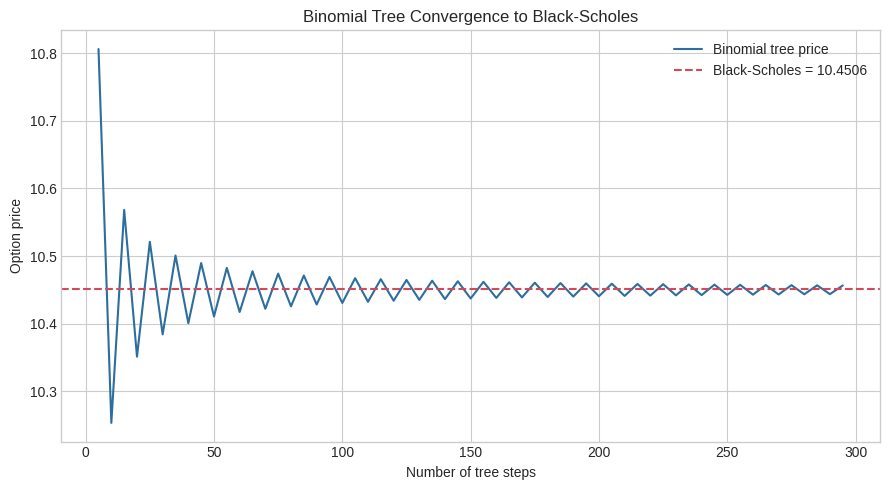

In [3]:
steps_range = np.arange(5, 300, 5)
tree_prices = [binomial_price(s, k, r, sigma, T, n_steps=n, option_type="call", exercise="european")
               for n in steps_range]

plt.figure(figsize=(9, 5))
plt.plot(steps_range, tree_prices, label="Binomial tree price", color="#2c6e9e")
plt.axhline(bs, color="#d1495b", linestyle="--", label=f"Black-Scholes = {bs:.4f}")
plt.xlabel("Number of tree steps")
plt.ylabel("Option price")
plt.title("Binomial Tree Convergence to Black-Scholes")
plt.legend()
plt.tight_layout()
plt.show()


The tree oscillates around the Black-Scholes value for small step counts (a known
artifact of the CRR discretization) and converges as steps increase. This is why
production trees typically use a few hundred steps, or a variant like the
Leisen-Reimer tree that damps the oscillation.

## 3. Where the tree earns its keep: American early exercise

In [4]:
euro_put = binomial_price(s, k, r, sigma, T, n_steps=500, option_type="put", exercise="european")
amer_put = binomial_price(s, k, r, sigma, T, n_steps=500, option_type="put", exercise="american")
early_exercise_premium = amer_put - euro_put

print(f"European put : {euro_put:.4f}")
print(f"American put : {amer_put:.4f}")
print(f"Early-exercise premium: {early_exercise_premium:.4f}")


European put : 5.5695
American put : 6.0888
Early-exercise premium: 0.5193


The American put is worth strictly more because the holder can exercise early to
lock in intrinsic value and reinvest — valuable when the put is deep in-the-money
and interest rates are high enough to make early cash preferable. Black-Scholes has
no way to express this; it only prices European exercise.

## 4. Greeks: analytical (Black-Scholes) vs. finite-difference (Monte Carlo)

In [5]:
bs_g = bs_greeks(s, k, r, sigma, T, "call")
mc_g = mc_greeks_bump(s, k, r, sigma, T, "call", n_paths=200_000)

print(f"{'Greek':<8}{'Black-Scholes':>16}{'Monte Carlo':>16}")
for greek in ["delta", "gamma", "vega"]:
    print(f"{greek:<8}{bs_g[greek]:>16.4f}{mc_g[greek]:>16.4f}")


Greek      Black-Scholes     Monte Carlo
delta             0.6368          0.6377
gamma             0.0188          0.0184
vega             37.5240         37.6842


Monte Carlo Greeks are computed by *bumping* an input (e.g. spot price) and
re-pricing — using the **same random draws** before and after the bump (common
random numbers) is what keeps the finite difference clean instead of drowning
in simulation noise. This bump-and-reprice technique is how Greeks get computed
for products that don't have a closed-form sensitivity.

## 5. How Delta and Gamma shift with spot and time to expiry

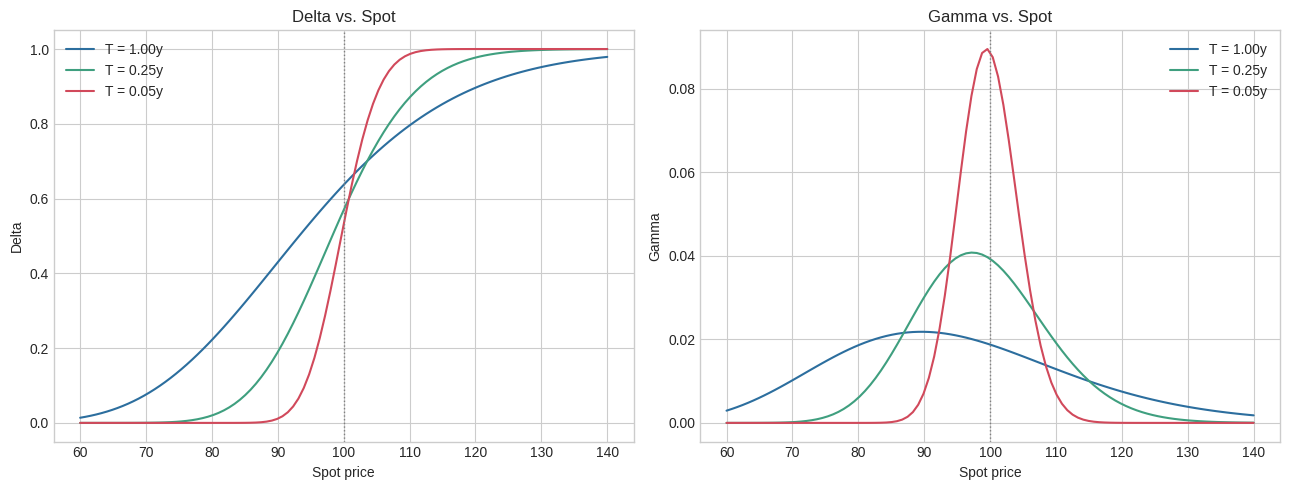

In [6]:
spot_range = np.linspace(60, 140, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for T_i, color in zip([1.0, 0.25, 0.05], ["#2c6e9e", "#3f9f7f", "#d1495b"]):
    deltas = [bs_greeks(s_i, k, r, sigma, T_i, "call")["delta"] for s_i in spot_range]
    gammas = [bs_greeks(s_i, k, r, sigma, T_i, "call")["gamma"] for s_i in spot_range]
    axes[0].plot(spot_range, deltas, label=f"T = {T_i:.2f}y", color=color)
    axes[1].plot(spot_range, gammas, label=f"T = {T_i:.2f}y", color=color)

axes[0].set_title("Delta vs. Spot")
axes[0].set_xlabel("Spot price")
axes[0].set_ylabel("Delta")
axes[0].axvline(k, color="gray", linestyle=":", linewidth=1)
axes[0].legend()

axes[1].set_title("Gamma vs. Spot")
axes[1].set_xlabel("Spot price")
axes[1].set_ylabel("Gamma")
axes[1].axvline(k, color="gray", linestyle=":", linewidth=1)
axes[1].legend()

plt.tight_layout()
plt.show()


As expiry approaches (T -> 0), Delta steepens into a step function around the strike
(the option behaves more like a binary bet on finishing in/out of the money), and
Gamma spikes sharply at-the-money — this is the "pin risk" options traders worry
about near expiry: small spot moves cause large swings in hedge ratio right when
there's little time left to react.

## 6. Recovering implied volatility

In [7]:
# Simulate "the market quotes this price" and recover sigma from it
market_price = 12.50
iv = implied_vol(market_price, s, k, r, T, "call")
print(f"Market price {market_price} implies volatility of {iv:.4%}")
print(f"(Sanity check: re-pricing at that vol gives back {bs_price(s, k, r, iv, T, 'call'):.4f})")


Market price 12.5 implies volatility of 25.4333%
(Sanity check: re-pricing at that vol gives back 12.5000)


---
### Next in this portfolio
- **Longstaff-Schwartz**: Monte Carlo pricing for American options (the tree's
  approach doesn't scale to multiple underlyings or complex path-dependence — LSM does).
- **Implied volatility surface**: apply `implied_vol()` across a full option chain
  to see the smile/skew, not just a single point.
- **Monte Carlo risk (VaR/CVaR)**: reuse the GBM/jump-diffusion engine from `core/`
  to simulate portfolio-level risk rather than a single option.
